# Research Methods <br>UHH - Knowledge Technology Research Group - WiSe 2025/2026
## Assignment #2 - Empirical Studies & EDA

***
### Group: A
### Names of members:  Niloufar Baba Ahmadi, Narges Baba Ahmadi, Alexandra Helen Hooser

***

### Instructions:

Please answer the questions below. Copy this notebook and enter your answers underneath each task description, inserting cells as needed. You may use a combination of [python 3](https://www.python.org), [markdown](http://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html), and [LaTeX](https://towardsdatascience.com/write-markdown-latex-in-the-jupyter-notebook-10985edb91fd) to formulate your responses. In order to successfully complete the assignment, you will need the lecture material provided in the [RM moodle course](https://lernen.min.uni-hamburg.de/course/view.php?id=5728), especially L02 & L03.

**Make sure to use only a copy of this notebook for your answers instead of a new/blank notebook.**

### Grading Criteria:

In order to successfully pass this assignment, you will need **at least a total of 70 points out of 100 points**, and every task has to be tackled.

### Submission:

Please upload the following two files **until Tuesday, November 4, 2025, 20:00 CET (Germany)** together in a .zip archive in moodle:
1. a (single) copy of this jupyter notebook containing your answers for all tasks (file extension: .ipynb)
2. an [exported PDF document](https://jupyterlab.readthedocs.io/en/stable/user/export.html) of the jupyter notebook (file extension: .pdf)

### Presentation:

Make sure that each (!) group member takes part in solving this assignment and is prepared to answer questions and/or present solutions from your submitted notebook during our assignment revision meeting scheduled for **Wednesday, November 12, 2025, 10:00 - 13:00 CET (Germany)**.

### File Naming:

Add the group letter to the file name prior to submission. For example, if your group letter is "A" (see group selection in moodle), you would use the following filename:
1. RM_A02_Group_A.ipynb
2. RM_A02_Group_A.pdf

***
***

#### Task 1 **[10 points] Data Scales**

1. For each of the features in the CRU dataset (e.g., precipitation), identify all scales of data whose definition is valid for all entries in the columns that belong to that feature. Create a table using python code that contains all features as rows, data scales as columns, and binary table entries indicating whether the feature values (i.e., column entries in the dataset) correspond to the data scale or not.
2. For each of the features, briefly explain to which of the errors mentioned in the lecture this feature is prone.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from pandas.api.types import is_numeric_dtype, is_string_dtype
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

There are 82 columns so for the sake of simplicity we will cluster the features together. e.g. TMP MEAN of months could be one cluster and TMP MIN of months another

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/uhh/WiSo2025 26/RM seminar/A02 /data/CRU_data.csv')
# df = pd.read_csv('CRU_data.csv') #uncomment if you are running outside of drive :)
# df.describe()
col = df.columns
print(len(col))
col

82


Index(['COUNTRY', 'YEAR', 'TMP_MEAN_JAN', 'TMP_MEAN_FEB', 'TMP_MEAN_MAR',
       'TMP_MEAN_APR', 'TMP_MEAN_MAY', 'TMP_MEAN_JUN', 'TMP_MEAN_JUL',
       'TMP_MEAN_AUG', 'TMP_MEAN_SEP', 'TMP_MEAN_OCT', 'TMP_MEAN_NOV',
       'TMP_MEAN_DEC', 'TMP_MEAN_MAM', 'TMP_MEAN_JJA', 'TMP_MEAN_SON',
       'TMP_MEAN_DJF', 'TMP_MIN_JAN', 'TMP_MIN_FEB', 'TMP_MIN_MAR',
       'TMP_MIN_APR', 'TMP_MIN_MAY', 'TMP_MIN_JUN', 'TMP_MIN_JUL',
       'TMP_MIN_AUG', 'TMP_MIN_SEP', 'TMP_MIN_OCT', 'TMP_MIN_NOV',
       'TMP_MIN_DEC', 'TMP_MIN_MAM', 'TMP_MIN_JJA', 'TMP_MIN_SON',
       'TMP_MIN_DJF', 'TMP_MAX_JAN', 'TMP_MAX_FEB', 'TMP_MAX_MAR',
       'TMP_MAX_APR', 'TMP_MAX_MAY', 'TMP_MAX_JUN', 'TMP_MAX_JUL',
       'TMP_MAX_AUG', 'TMP_MAX_SEP', 'TMP_MAX_OCT', 'TMP_MAX_NOV',
       'TMP_MAX_DEC', 'TMP_MAX_MAM', 'TMP_MAX_JJA', 'TMP_MAX_SON',
       'TMP_MAX_DJF', 'WET_DAYS_JAN', 'WET_DAYS_FEB', 'WET_DAYS_MAR',
       'WET_DAYS_APR', 'WET_DAYS_MAY', 'WET_DAYS_JUN', 'WET_DAYS_JUL',
       'WET_DAYS_AUG', 'WET_DAYS_SE

## Task 1 - 1

- COUNTRY is categorical because it represents names without any numerical or ordered meaning.

- YEAR is categorical, ordinal and interval since it is ordered and differences between years are meaningful, but the year zero is not a true absence of time because before year 0 history and time still existed and 0 here doesn't give a sense of nothingness.

- All temperature variables (TMP_MEAN, TMP_MIN, TMP_MAX) are categorical, ordinal and interval because temperature in °C can be ordered and differenced, but 0 °C does not mean the absence of temperature unlike Kelvin which has a meaningful 0.

- WET_DAYS and PRECIP are categorical, ordinal, interval and ratio since they are numeric, ordered and possess a true zero meaning 0 days or 0 mm indicate complete absence and "nothingness". There are minus values in both WET_DAYS and PRECIP which is probably a sign of missing values.

In [ ]:
# clusters = {
#         "TMP_MEAN": [c for c in df.columns if c.startswith("TMP_MEAN_")],
#         "TMP_MIN": [c for c in df.columns if c.startswith("TMP_MIN_")],
#         "TMP_MAX": [c for c in df.columns if c.startswith("TMP_MAX_")],
#         "WET_DAYS": [c for c in df.columns if c.startswith("WET_DAYS_")],
#         "PRECIP": [c for c in df.columns if c.startswith("PRECIP_")],
#     }

# df[clusters["TMP_MEAN"]].describe()
# df[clusters["TMP_MIN"]].describe()
# df[clusters["TMP_MAX"]].describe()
# df[clusters["WET_DAYS"]].describe()
# df[clusters["PRECIP"]].describe()


pd.DataFrame([
    ["Features", "Categorical", "Ordinal", "Interval", "Ratio"],
    ["COUNTRY", 1, 0, 0, 0],
    ["YEAR", 1, 1, 1, 0],
    ["TMP_MEAN", 1, 1, 1, 0],
    ["TMP_MIN", 1, 1, 1, 0],
    ["TMP_MAX", 1, 1, 1, 0],
    ["WET DAYS", 1, 1, 1, 1],
    ["PRECIP", 1, 1, 1, 1],
])

,0,1,2,3,4
0,Features,Categorical,Ordinal,Interval,Ratio
1,COUNTRY,1,0,0,0
2,YEAR,1,1,1,0
3,TMP_MEAN,1,1,1,0
4,TMP_MIN,1,1,1,0
5,TMP_MAX,1,1,1,0
6,WET DAYS,1,1,1,1
7,PRECIP,1,1,1,1


## Task 1 - 2

- **COUNTRY**
- - Effect of an independent variable: border changes and foreing policies can change who is counted as a “COUNTRY” or a certain “COUNTRY” may cease to exist.

- **YEAR**
- - No Error Types

- **TMP_MEAN / TMP_MIN / TMP_MAX (°C)**
- - Measurement error: sensor calibration and general sensor errors
- - Sampling error: Different countries use different sensors that have varied accuraies and percisions.
- - Effect of an independent variable: Not all sensors are placed in similar positions which could also affect the results they show (e.g. sensors placed on different elavations can not be comparable.)

- **WET_DAYS (count of days with precip)**
- - Measurement error: The tool's error and caliberation errors could lead to missing "WET_DAYS"
- - Sampling error: Different sensors are used or they could change the sensor technology between these years which could cause more/less days to be counted as "WET_DAYS"
- - Effect of an independent variable: local environmental conditions (where the sensor is placed) and also different countries could define "WET_DAYS" differently.

- **PRECIP**
- - Measurement error: The tool's error and caliberation errors
- - Sampling error: Different sensors are used or they could change the sensor technology between these years.
- - Effect of an independent variable: local environmental conditions like elevation or nearby water bodies can influence how much precipitation is recorded.



#### Task 2 **[10 points] Types of Experiments**

Different types of studies and experiments were discussed in the lecture. With respect to climate data, state whether it is possible to conduct the following experiments given below. Briefly explain your reasoning and give an example for each of the four types.

1. Exploratory study
2. Assessment study
3. Observation experiments
4. Manipulation experiments


## Task 2

1. Exploratory study ➡ Possible
- - It is just looking at the statics like descriptive or visual explorations of the available climate data to spot patterns and trends. No hypothesis or manipulation is required. E.g. clustering countries by seasonal or monthly TMP_MEAN to generate hypotheses about different climates or plotting the PRECIP trend through the years.

2. Assessment study ➡ Possible
- - According to lecture, it is an exploratory study but structured where you can test limits/ranges of variables or methods and see what that changes. For example for this dataset we can check the valid range of “wet days” and see how changing a “wet day” threshold (≥0.1 mm vs ≥1 mm) affects countries' totals.

3. Observation experiments ➡ Possible
- - Tests a model's predictions against new observations **without** manipulating the system and confirms or rejects a hypothesis using observational data. As for this dataset we could devide the data into test and train then train a hypothetical model on the train data and test it on the test data that it has not yet seen and according to our accuracy results confirms or reject this hypothetical model.

4. Manipulation experiments ➡ Not compeletly possible (depends)

- - In the real climate system it is not possible since the real world is big and it is hard to stop unknown variables from affecting the experiment; However, using simulators or labratories that simulate the real world it can be doable. We can't ethically create more CO_2 in certain cities, but we can run controlled experiments or very limited field manipulations. So **true manipulation** is not possible.


#### Task 3 **[40 points] Visualization**

Plot the four statistics given below using suitable python packages:

1. Timeline of cumulative precipitation over the course of the year 2024. _(i)_ world-wide and _(ii)_ per country.
2. Average precipitation per wetday per country in 2024.
3. Climate diagram based on the average data from the last decade (2015 - 2024) for one country of your choice.<br> _Note: Include the amount of precipitation as well as min, mean, and max temperature._ <br> _Hint: Check out online how climate diagrams typically look like._
4. Frequency distribution of mean temperatures in Germany in the timespans (i) 1904-1924 and (ii) 2004-2024. <br> _Note: Use appropriate, common bins for both diagrams._

As a reminder, the following instructions will apply to **all visualization tasks** as part of the RM course: Make sure to use appropriate plot types for visualization (e.g., histogram, bar plot, scatter plot, line plot, ...) and proper axis labeling/scaling. Add a legend to each plot to facilitate the viewer's understanding. Make sure to describe/interpret the outcome of your visualization.

_Hint: It might be helpful to use the [wide__to__long](https://pandas.pydata.org/docs/reference/api/pandas.wide_to_long.html) function in pandas to format the data for plotting!_ <br>

## Task 3 - 1 (i)

Timeline of cumulative precipitation over the course of the year 2024 world-wide:  

There was consistent precipitation throughout 2024, with no large dry periods because the line never flattens. The slope slightly steepens around May to August, suggesting perhaps a more intense rain during those months. The world accumulated 854.7 mm of total precipitation by the end of 2024.

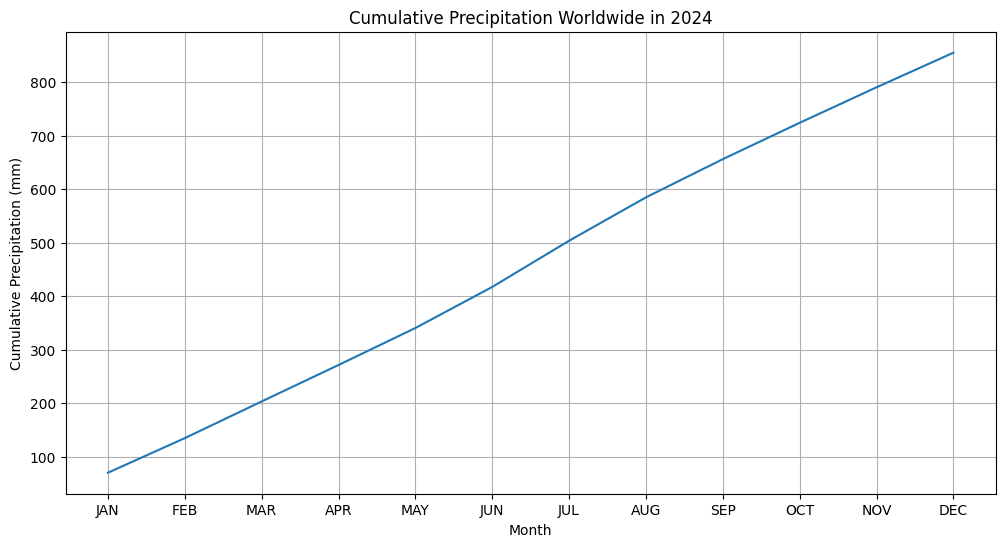

In [ ]:
df_2024 = df[df['YEAR'] == 2024].copy()
# df_2024

seasonal_cols = ['PRECIP_MAM', 'PRECIP_JJA', 'PRECIP_SON', 'PRECIP_DJF']
precip_cols = [c for c in df.columns if c.startswith("PRECIP_") and c not in seasonal_cols]
df_precip_2024 = df_2024[['COUNTRY'] + precip_cols]
# df_precip_2024

df_precip_2024_long = pd.wide_to_long(df_precip_2024, stubnames='PRECIP', i='COUNTRY', j='MONTH', suffix='_(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)').reset_index()
df_precip_2024_long['MONTH'] = df_precip_2024_long['MONTH'].str.strip('_')
# df_precip_2024_long

df_precip_2024_long['Cumulative_Precipitation'] = df_precip_2024_long.groupby('COUNTRY')['PRECIP'].cumsum()
df_precip_2024_long_world = df_precip_2024_long[df_precip_2024_long['COUNTRY'] == 'WORLD']
# df_precip_2024_long_world

plt.figure(figsize=(12, 6))
plt.plot(df_precip_2024_long_world['MONTH'], df_precip_2024_long_world['Cumulative_Precipitation'])
plt.xlabel('Month')
plt.ylabel('Cumulative Precipitation (mm)')
plt.title('Cumulative Precipitation Worldwide in 2024')
plt.grid(True)
plt.show()


## Task 3 - 1 (ii)

Timeline of cumulative precipitation over the course of the year 2024 per country:

- Steeper slopes indicate months with heavier rainfall, while flat sections indicate dry periods.

- The country with the Most Rainfall is South Korea (1419 mm) with highest cumulative precipitation. During June to September the slope steepens suggesting it is the rain season there.

- India (1256.5 mm) has the second highest rainfall among the countries in the data with big jumps from June to October, but is relatively flat in January to April suggesting a dryer season.

- Ethiopia and Nepal are also high in rainfall and both seem flatter from October to Februrary. A period lower in Rainfall. Also Both experience heavy rains mid-year (May to September).

- Moderate Rainfall Countries are Germany, China, Spain and Turkey. Germany's rainfall is steady, but Spain shows a large spike in September to October. Turkey also has gradual and steady increase. China has gradual rainfall increases with a clear wet season around June to August.

- Afghanistan (369.3 mm) and Iran (236.3 mm) have modest rainfall mostly early in the year (Jan to May), with dry summers.

- Pakistan has small peaks in June to August, likely it's a rain season and Kazakhstan shows steady but light precipitation throughout the year.


- Low Rainfall Countries are Tunisia (229.6 mm) and Egypt (19.5 mm) and   have very low totals. Their lines are almost flat, showing little to no rain most months.

/tmp/ipython-input-369814881.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(ordered_countries))


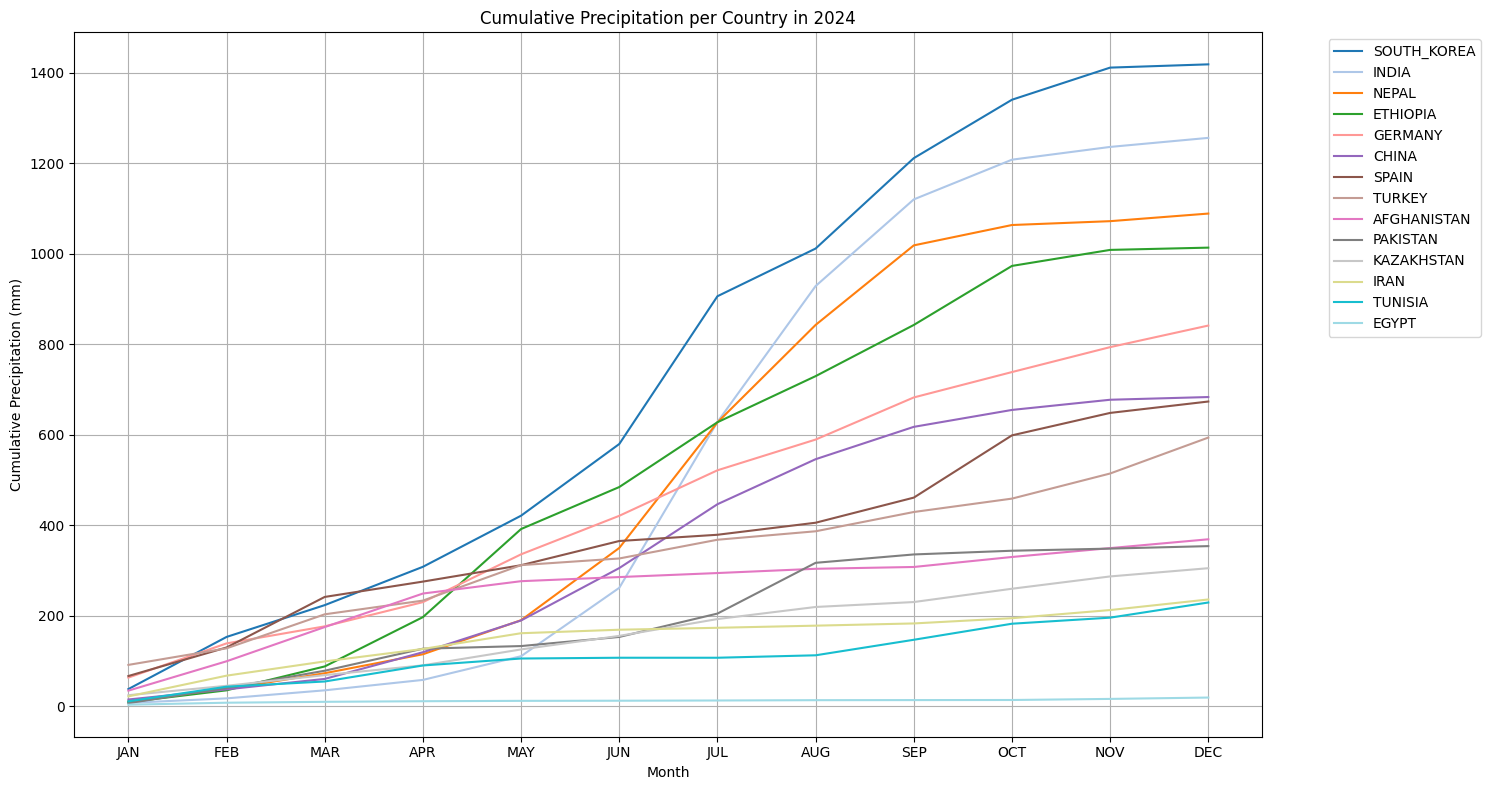

In [ ]:
plt.figure(figsize=(15, 8))

# To make the plot readable, I have ranked the countries on the plot according to their cumulative precipitation in a year and use more colors
final_precip = df_precip_2024_long[df_precip_2024_long['MONTH'] == 'DEC'].sort_values(by='Cumulative_Precipitation', ascending=False)
ordered_countries = final_precip['COUNTRY'].tolist()
colors = cm.get_cmap('tab20', len(ordered_countries))

for i, country in enumerate(ordered_countries):
    if country != 'WORLD':
        country_data = df_precip_2024_long[df_precip_2024_long['COUNTRY'] == country]
        # print(country_data)
        plt.plot(country_data['MONTH'], country_data['Cumulative_Precipitation'], label=country, color=colors(i))

plt.xlabel('Month')
plt.ylabel('Cumulative Precipitation (mm)')
plt.title('Cumulative Precipitation per Country in 2024')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Task 3 - 2

Average precipitation per wetday per country in 2024:

- India (~22 mm) has heavy rain days and ranks with the highest average among all other countries. India has concentrated heavy raind meaning fewer wet days and heavy intensity.

- Other heavy rainy-day countries (10-15 mm) are Ethiopia ~13.9, Nepal ~12.4 and South Korea ~11.8. Ethiopia also has low frequency and high intensity of rain while Nepal and South Korea have high frequency and high intensity of rain.

- Moderate rainy-day countries (6-10 mm) are Afghanistan ~7.9, Pakistan ~7.7 and China ~6.7. China has high frequency and relatively high intensity of rain, but Afghanistan and Pakistan have low frequency and relatively high intensity of rain.

- Light rainy-day countries (4-6 mm) are Tunisia ~5.7, Turkey ~5.4, Spain ~5.4, Iran ~4.6 and Germany ~4.4. Tunesia and Iran both have a low frequency and a low intensity of rain while the rest have a high frequency and a low intensity of rain.

- Very light rainy-day countries (≤ 4 mm) are Egypt ~2.9 and Kazakhstan ~2.8. Kazakhstan has high frequency and low intensity of rain while Egypt has Low frequency and low intensity of rain.

        COUNTRY  Total_Wet_Days  Total_Precipitation  Avg_Precip_Per_Wet_Day
0         INDIA            57.1               1256.5               22.005254
1      ETHIOPIA            73.1               1013.9               13.870041
2         NEPAL            87.9               1089.2               12.391354
3   SOUTH_KOREA           119.7               1419.0               11.854637
4   AFGHANISTAN            46.6                369.3                7.924893
5      PAKISTAN            45.7                354.2                7.750547
6         CHINA           101.4                683.7                6.742604
7       TUNISIA            40.4                229.6                5.683168
8        TURKEY           109.2                594.1                5.440476
9         SPAIN           125.3                673.8                5.377494
10         IRAN            51.2                236.3                4.615234
11      GERMANY           189.8                841.7                4.434668

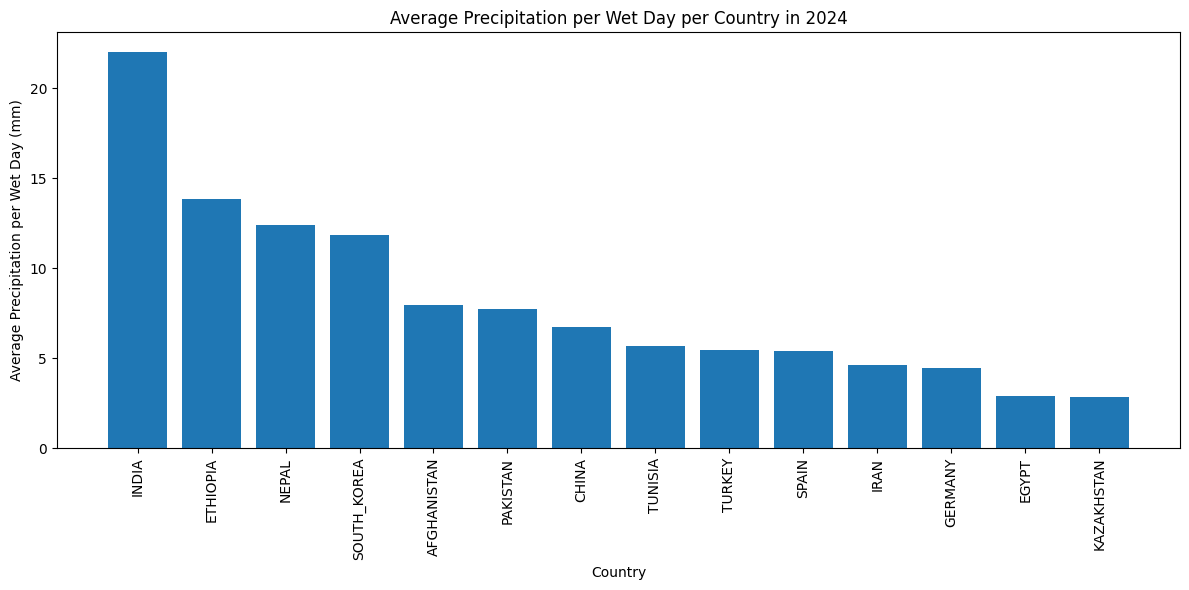

In [ ]:
wet_days_cols = [c for c in df.columns if c.startswith("WET_DAYS_") and c not in ['WET_DAYS_MAM', 'WET_DAYS_JJA', 'WET_DAYS_SON', 'WET_DAYS_DJF']]
df_wet_precip_2024 = df_2024[['COUNTRY'] + wet_days_cols + precip_cols].copy()

df_wet_precip_2024['Total_Wet_Days'] = df_wet_precip_2024[wet_days_cols].sum(axis=1)
df_wet_precip_2024['Total_Precipitation'] = df_wet_precip_2024[precip_cols].sum(axis=1)

# no country had 0 wet days so the case is not handeled
df_wet_precip_2024['Avg_Precip_Per_Wet_Day'] = df_wet_precip_2024.apply(lambda row: row['Total_Precipitation'] / row['Total_Wet_Days'], axis=1)

df_avg_precip_per_wet_day = df_wet_precip_2024[df_wet_precip_2024['COUNTRY'] != 'WORLD'].sort_values(by='Avg_Precip_Per_Wet_Day', ascending=False).reset_index()

print(df_avg_precip_per_wet_day[['COUNTRY', 'Total_Wet_Days', 'Total_Precipitation', 'Avg_Precip_Per_Wet_Day']])

plt.figure(figsize=(12, 6))
plt.bar(df_avg_precip_per_wet_day['COUNTRY'], df_avg_precip_per_wet_day['Avg_Precip_Per_Wet_Day'])
plt.xlabel('Country')
plt.ylabel('Average Precipitation per Wet Day (mm)')
plt.title('Average Precipitation per Wet Day per Country in 2024')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Task 3 - 3


### **Climate Diagram of Germany (Average 2015–2024)**

The diagram shows the relationship between **temperature** and **precipitation** across months in Germany, averaged over the decade 2015–2024.

1. **Temperature Trends:**

   * The **mean temperature** (orange line) starts low at around **1–2 °C** in January and steadily rises, peaking around **18–20 °C** in **July–August**.
   * The **minimum temperature** (blue dashed line) stays below 0 °C in winter and rises to about **13–14 °C** in summer.
   * The **maximum temperature** (red dashed line) ranges from about **4–5 °C** in January to around **25°C** in July–August.
   * The symmetrical curve shows a **typical temperate climate pattern**, with warm summers and cold winters.

2. **Precipitation Patterns:**

   * The **precipitation bars** (light blue) show that rainfall occurs throughout the year, indicating no distinct dry season.
   * Monthly precipitation values fluctuate between **40 mm and 75 mm**, with slightly higher rainfall in **May–August**, suggesting **wetter summers**.

3. **Seasonal Climate Characteristics:**

   * **Winter (Dec–Feb):** Cold, with mean temperatures around or below 2 °C and moderate rainfall (~50 mm/month).
   * **Spring (Mar–May):** Gradual warming and increasing rainfall.
   * **Summer (Jun–Aug):** Warmest period, with high mean and max temperatures and frequent rainfall peaks — typical of **humid continental climates**.
   * **Autumn (Sep–Nov):** Steady cooling with precipitation remaining moderate.

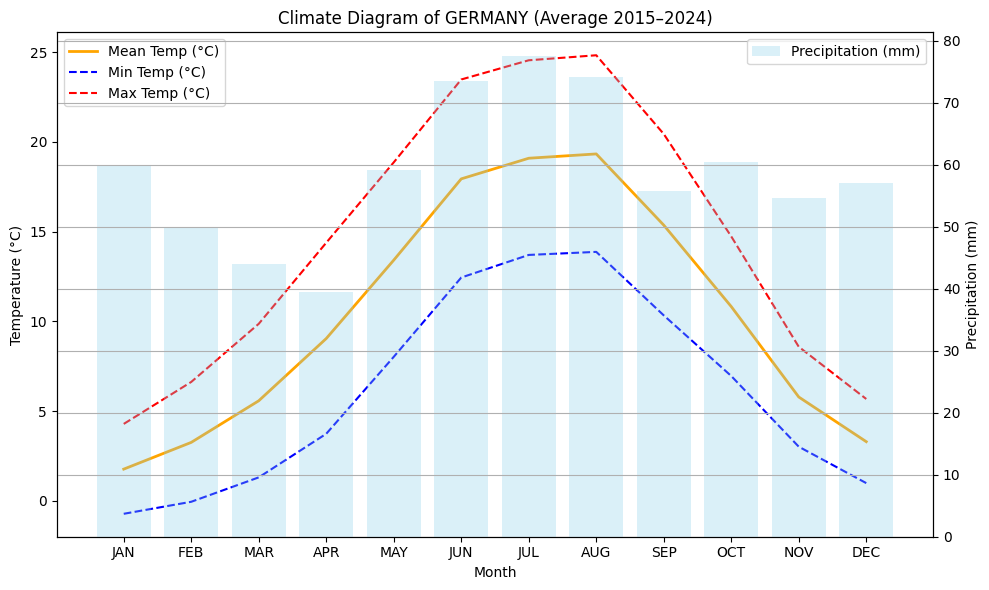

In [ ]:
country = 'GERMANY'
df_decade = df[(df['COUNTRY'] == country) & (df['YEAR'].between(2015, 2024))].copy()

months = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
temp_mean_cols = [f'TMP_MEAN_{m}' for m in months]
temp_min_cols = [f'TMP_MIN_{m}' for m in months]
temp_max_cols = [f'TMP_MAX_{m}' for m in months]
precip_cols = [f'PRECIP_{m}' for m in months]

# averages over the last decade
avg_temp_mean = df_decade[temp_mean_cols].mean()
avg_temp_min = df_decade[temp_min_cols].mean()
avg_temp_max = df_decade[temp_max_cols].mean()
avg_precip = df_decade[precip_cols].mean()

# Combine for plotting
climate_df = pd.DataFrame({
    'Month': months,
    'Temp_Min': avg_temp_min.values,
    'Temp_Mean': avg_temp_mean.values,
    'Temp_Max': avg_temp_max.values,
    'Precipitation': avg_precip.values
})


fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(climate_df['Month'], climate_df['Temp_Mean'], label='Mean Temp (°C)', color='orange', linewidth=2)
ax1.plot(climate_df['Month'], climate_df['Temp_Min'], label='Min Temp (°C)', color='blue', linestyle='--')
ax1.plot(climate_df['Month'], climate_df['Temp_Max'], label='Max Temp (°C)', color='red', linestyle='--')
ax1.set_xlabel('Month')
ax1.set_ylabel('Temperature (°C)')
ax1.tick_params(axis='y', labelcolor='black')


ax2 = ax1.twinx()
ax2.bar(climate_df['Month'], climate_df['Precipitation'], alpha=0.3, color='skyblue', label='Precipitation (mm)')
ax2.set_ylabel('Precipitation (mm)')
ax2.tick_params(axis='y', labelcolor='black')

plt.title(f'Climate Diagram of {country} (Average 2015–2024)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


## Task 3 - 4

### **Interpretation: Frequency Distribution of Mean Annual Temperatures in Germany (1904–1924 vs. 2004–2024)**

The two histograms show the distribution of Germany’s mean annual temperatures across two 20-year periods using identical bins for fair comparison.

* **1904–1924:** Temperatures are concentrated between **7 °C and 9 °C**, with most years around **8 °C**, indicating a **cooler and more stable climate** in the early 20th century.
* **2004–2024:** The distribution shifts clearly toward **higher temperatures (9–11 °C)**, showing that **recent decades are noticeably warmer**. The frequency of cooler years has disappeared entirely.
* **Overall:** The rightward shift of the distribution reflects a **warming of roughly 2–3 °C** in Germany’s average annual temperature over the past century, consistent with broader global climate warming trends.



/tmp/ipython-input-3944422903.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  period1['Annual_Mean_Temp'] = period1[temp_cols].mean(axis=1)
/tmp/ipython-input-3944422903.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  period2['Annual_Mean_Temp'] = period2[temp_cols].mean(axis=1)


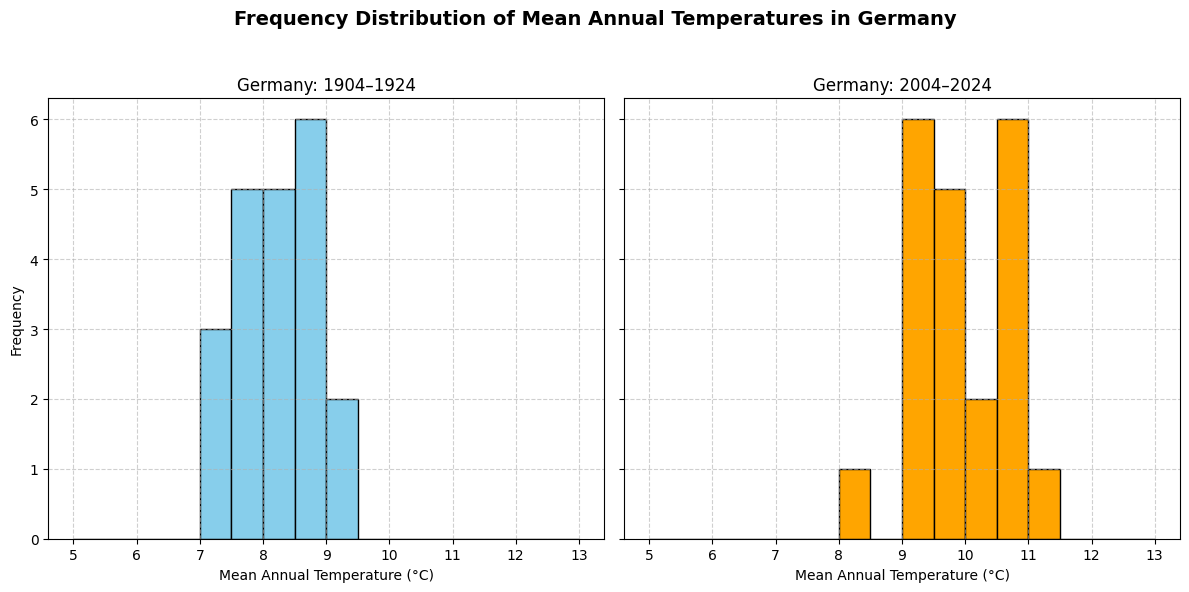

In [ ]:
df_germany = df[df['COUNTRY'] == 'GERMANY'].copy()


period1 = df_germany[(df_germany['YEAR'] >= 1904) & (df_germany['YEAR'] <= 1924)]
period2 = df_germany[(df_germany['YEAR'] >= 2004) & (df_germany['YEAR'] <= 2024)]


months = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
temp_cols = [f'TMP_MEAN_{m}' for m in months]


period1['Annual_Mean_Temp'] = period1[temp_cols].mean(axis=1)
period2['Annual_Mean_Temp'] = period2[temp_cols].mean(axis=1)

bins = np.linspace(5, 13, 17)  # ensures both plots share same scale


fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# 1904–1924
axes[0].hist(period1['Annual_Mean_Temp'], bins=bins, color='skyblue', edgecolor='black')
axes[0].set_title('Germany: 1904–1924')
axes[0].set_xlabel('Mean Annual Temperature (°C)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2004–2024
axes[1].hist(period2['Annual_Mean_Temp'], bins=bins, color='orange', edgecolor='black')
axes[1].set_title('Germany: 2004–2024')
axes[1].set_xlabel('Mean Annual Temperature (°C)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Frequency Distribution of Mean Annual Temperatures in Germany', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Task 4 **[40 points] EDA**

Following the Titanic example from the lecture, we want to gain first insights into multivariate EDA. We want to see if the climate warming is different between countries. For this purpose, take the following steps using python to answer the question **whether the number of warmer/colder months (compared to 50 years ago) changes between countries and whether there is a difference between decades.**

For this task use the data from Pakistan and Spain starting from the year 1964.

1. For each month, calculate if it was warmer or colder compared to the same month 50 years ago (e.g., you compare 01/1964 with 01/1914, then 02/1964 with 02/1914, ...).
2. Create two contingency tables of **total number of warmer and colder months per country** (one containing the absolute counts and the second one containing row and column proportions).
3. Create another two contingency tables of **total number of warmer and colder months per decade** (one containing the absolute counts and the second one containing row and column proportions).
4. Plot a histogram or bar chart that shows the **total number of warmer months by country and decade**.
   _Hint: The usage of different colors might help a lot!_
6. Now combine the contingency tables of task 4.2 and 4.3 (see Titanic example discussed in the EDA lecture), so that you have a subdivision into countries by decade, with absolute counts and row/column proportions.
7. Calculate the expected frequencies $f_e$ for each conjunct event in the contingency table from task 4.5 and create a copy of the table from task 4.5 containing the $f_e$ values.
8. Calculate $\chi²_{Pakistan}$ and $\chi²_{Spain}$ and interpret.
9. What does a small $\chi²$ value mean? What if it's zero? Explain.

## Task 4 - 1

In the 50 years between 1964 and 2014, **Pakistan** experienced warming in nearly all months except February and March, with the strongest increases in winter and early summer.

**Spain** also shows an overall warming trend, though with slight cooling in May, July, and September, indicating more variable seasonal changes.

In [ ]:
countries = ['PAKISTAN', 'SPAIN']
months = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']

records = []

for country in countries:
    country_df = df[df['COUNTRY'] == country]

    if 1964 in country_df['YEAR'].values and 2014 in country_df['YEAR'].values:
        row_1964 = country_df[country_df['YEAR'] == 1964]
        row_2014 = country_df[country_df['YEAR'] == 2014]

        for m in months:
            col = f'TMP_MEAN_{m}'
            tmp_1964 = float(row_1964[col])
            tmp_2014 = float(row_2014[col])
            diff = tmp_2014 - tmp_1964

            if diff > 0:
                status = 'Warmer'
            elif diff < 0:
                status = 'Colder'
            else:
                status = 'Same'

            records.append({
                'COUNTRY': country,
                'MONTH': m,
                'TMP_1964': tmp_1964,
                'TMP_2014': tmp_2014,
                'DIFF': diff,
                'STATUS': status
            })

df_compare_1964_2014 = pd.DataFrame(records)

# Sort by month order
df_compare_1964_2014['MONTH'] = pd.Categorical(df_compare_1964_2014['MONTH'], categories=months, ordered=True)
df_compare_1964_2014 = df_compare_1964_2014.sort_values(['COUNTRY','MONTH']).reset_index(drop=True)

print(df_compare_1964_2014)


     COUNTRY MONTH  TMP_1964  TMP_2014  DIFF  STATUS
0   PAKISTAN   JAN       6.1       9.3   3.2  Warmer
1   PAKISTAN   FEB      11.0      10.3  -0.7  Colder
2   PAKISTAN   MAR      18.0      16.3  -1.7  Colder
3   PAKISTAN   APR      22.4      22.5   0.1  Warmer
4   PAKISTAN   MAY      25.9      26.2   0.3  Warmer
5   PAKISTAN   JUN      28.4      30.6   2.2  Warmer
6   PAKISTAN   JUL      28.4      29.9   1.5  Warmer
7   PAKISTAN   AUG      28.3      28.5   0.2  Warmer
8   PAKISTAN   SEP      25.1      26.4   1.3  Warmer
9   PAKISTAN   OCT      19.7      22.6   2.9  Warmer
10  PAKISTAN   NOV      14.0      16.2   2.2  Warmer
11  PAKISTAN   DEC       8.8      10.4   1.6  Warmer
12     SPAIN   JAN       5.1       7.9   2.8  Warmer
13     SPAIN   FEB       7.5       7.7   0.2  Warmer
14     SPAIN   MAR       8.7       9.9   1.2  Warmer
15     SPAIN   APR      10.8      13.5   2.7  Warmer
16     SPAIN   MAY      17.0      15.7  -1.3  Colder
17     SPAIN   JUN      19.2      20.0   0.8  

/tmp/ipython-input-1260063115.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  tmp_1964 = float(row_1964[col])
/tmp/ipython-input-1260063115.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  tmp_2014 = float(row_2014[col])


## Task 4 - 2

Both countries show a clear warming tendency between 1964 and 2014.

Pakistan experienced warmer conditions in about 83% of months, slightly higher than Spain’s 75%, indicating stronger overall warming in Pakistan.

In [ ]:
# Absolute counts of Warmer/Colder months
ct_abs = pd.crosstab(df_compare_1964_2014['COUNTRY'], df_compare_1964_2014['STATUS'])
print("Contingency Table (Absolute Counts):\n")
print(ct_abs)

# Proportional version
ct_prop = pd.crosstab(df_compare_1964_2014['COUNTRY'], df_compare_1964_2014['STATUS'], normalize='all')
print("\nContingency Table (Proportions - Overall):\n")
print(ct_prop.round(3))

# Row-wise proportions
ct_row = pd.crosstab(df_compare_1964_2014['COUNTRY'], df_compare_1964_2014['STATUS'], normalize='index')
print("\nRow-wise Proportions (within each country):\n")
print(ct_row.round(3))


Contingency Table (Absolute Counts):

STATUS    Colder  Warmer
COUNTRY                 
PAKISTAN       2      10
SPAIN          3       9

Contingency Table (Proportions - Overall):

STATUS    Colder  Warmer
COUNTRY                 
PAKISTAN   0.083   0.417
SPAIN      0.125   0.375

Row-wise Proportions (within each country):

STATUS    Colder  Warmer
COUNTRY                 
PAKISTAN   0.167   0.833
SPAIN      0.250   0.750


## Task 4 - 3

These results reveal a clear long-term warming pattern in both Pakistan and Spain when compared to the baseline year 1964, though the intensity and timing of change differ between them.

In **Pakistan**, the proportion of warmer months steadily rises from **62% in the 1960s** to nearly **88% in the 2020s**, showing a consistent and accelerating warming trend across decades. The 2000s mark a turning point where warm months strongly outnumber cold ones, suggesting sustained temperature increases across all seasons.

In contrast, **Spain** begins with a cooler phase in the 1960s and 1970s—where colder months dominate, but transitions to a strong warming trend from the **1980s onward**, with **85% of months warmer than in 1964 by the 2020s**.

Overall, while both countries exhibit significant warming, **Pakistan shows an earlier and slightly stronger increase**, whereas **Spain’s warming intensified later**, reflecting regional differences in how climate change manifests over time.


In [ ]:
countries = ['PAKISTAN', 'SPAIN']
months = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']

ct_dict = {} #for Q. 4.4
ct_dict_all = {} #for Q. 4.5

for country in countries:
    print(f"\n============================")
    print(f"Country: {country}")
    print(f"============================\n")

    records = []
    country_df = df[df['COUNTRY'] == country].copy()
    baseline = country_df[country_df['YEAR'] == 1964]

    for year in country_df['YEAR']:
        if year > 1964:  # compare only years after baseline
            current = country_df[country_df['YEAR'] == year]
            for m in months:
                col = f'TMP_MEAN_{m}'
                tmp_1964 = float(baseline[col])
                tmp_now = float(current[col])
                diff = tmp_now - tmp_1964

                if diff > 0:
                    status = 'Warmer'
                elif diff < 0:
                    status = 'Colder'
                else:
                    status = 'Same'

                records.append({
                    'COUNTRY': country,
                    'YEAR': year,
                    'MONTH': m,
                    'TMP_1964': tmp_1964,
                    'TMP_NOW': tmp_now,
                    'DIFF': diff,
                    'STATUS': status,
                    'DECADE': int(np.floor(year / 10) * 10)
                })

    df_decade_compare = pd.DataFrame(records)
    df_decade_compare = df_decade_compare[df_decade_compare['STATUS'] != 'Same']

    # Contingency Table: Absolute counts per decade
    ct_decade_abs = pd.crosstab(df_decade_compare['DECADE'], df_decade_compare['STATUS'])
    ct_dict[country] = ct_decade_abs
    print("Contingency Table (Absolute Counts per Decade):\n")
    print(ct_decade_abs)


    ct_decade_overall = pd.crosstab(df_decade_compare['DECADE'], df_decade_compare['STATUS'], normalize='all')
    ct_dict_all[country] = ct_decade_overall
    ct_decade_row = pd.crosstab(df_decade_compare['DECADE'], df_decade_compare['STATUS'], normalize='index')
    ct_dict_all[country] = ct_decade_row

    print("\nContingency Table (Proportions - Overall):\n")
    print(ct_decade_overall.round(3))

    print("\nRow-wise Proportions (within each decade):\n")
    print(ct_decade_row.round(3))



Country: PAKISTAN



/tmp/ipython-input-2529195630.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  tmp_1964 = float(baseline[col])
/tmp/ipython-input-2529195630.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  tmp_now = float(current[col])


Contingency Table (Absolute Counts per Decade):

STATUS  Colder  Warmer
DECADE                
1960        22      36
1970        36      80
1980        34      82
1990        36      83
2000        19      98
2010        16      99
2020         7      53

Contingency Table (Proportions - Overall):

STATUS  Colder  Warmer
DECADE                
1960     0.031   0.051
1970     0.051   0.114
1980     0.049   0.117
1990     0.051   0.118
2000     0.027   0.140
2010     0.023   0.141
2020     0.010   0.076

Row-wise Proportions (within each decade):

STATUS  Colder  Warmer
DECADE                
1960     0.379   0.621
1970     0.310   0.690
1980     0.293   0.707
1990     0.303   0.697
2000     0.162   0.838
2010     0.139   0.861
2020     0.117   0.883

Country: SPAIN



/tmp/ipython-input-2529195630.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  tmp_1964 = float(baseline[col])
/tmp/ipython-input-2529195630.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  tmp_now = float(current[col])


Contingency Table (Absolute Counts per Decade):

STATUS  Colder  Warmer
DECADE                
1960        34      23
1970        71      47
1980        47      69
1990        40      78
2000        31      85
2010        26      92
2020         9      51

Contingency Table (Proportions - Overall):

STATUS  Colder  Warmer
DECADE                
1960     0.048   0.033
1970     0.101   0.067
1980     0.067   0.098
1990     0.057   0.111
2000     0.044   0.121
2010     0.037   0.131
2020     0.013   0.073

Row-wise Proportions (within each decade):

STATUS  Colder  Warmer
DECADE                
1960     0.596   0.404
1970     0.602   0.398
1980     0.405   0.595
1990     0.339   0.661
2000     0.267   0.733
2010     0.220   0.780
2020     0.150   0.850


note by niloo: both row and column margines in different tables!

## Task 4 - 4
In this bar chart it can clearly be seen that over the decades the general trend of both Spain and Pakistan was an increase in warmer months, 2020 being an exception to this trend for both countries. Both countries had their highest report of warmer months in the 2010 decade. The lowest recording being in 1960.

The difference between 1960 and 1970 is large for Pakistan, however 1970 to 1990 there is little to change. An increase in 2000, little change for 2010 and then the staggering drop for 2020. Spain, on the other hand, has a steady incline from the 1960-2010, and then the sudden drop.

In 1990, the difference between Pakistan and Spain is the smallest.

This graph supports the argument made above that while both countries are experiencing warming, due to their regional differences, they are affected differently over time.

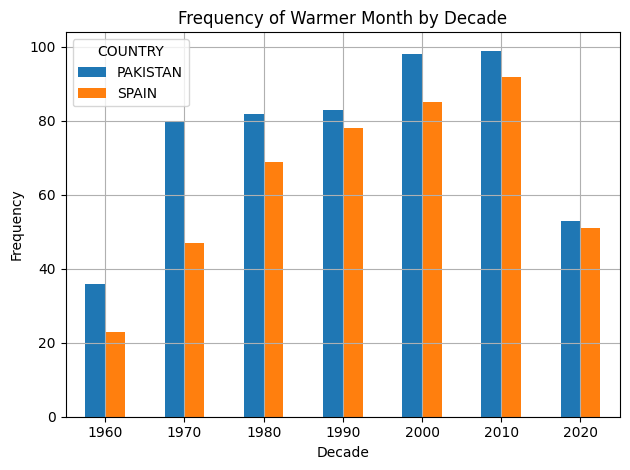

In [ ]:
combined = pd.concat(ct_dict, axis=0)

combined.index.names = ['COUNTRY', 'DECADE']

# print(combined)

plot_df = combined.unstack(level=0)

plot_df['Warmer'].plot(kind='bar')
plt.title("Frequency of Warmer Month by Decade")
plt.ylabel("Frequency")
plt.xlabel("Decade")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

## Task 4 - 5

This new contingency table combines the absolute values with the proportional ones as well as the totals of each row. This allows for an easier analysis using other statistical methods as well as a better overview.

In [ ]:
#getting and adjusting tables from previous questions
combined_ct_abs = pd.concat(ct_dict, names=["COUNTRY","DECADE"]).sort_index()
combined_ct_prop = pd.concat(ct_dict_all, names=["COUNTRY","DECADE"]).sort_index()

#total column
combined_ct_abs["TOTAL"] = combined_ct_abs.sum(axis=1)

#total row
totals_row = pd.DataFrame(combined_ct_abs.sum()).T
totals_row.index = pd.MultiIndex.from_tuples([("TOTAL","")],names=["COUNTRY","DECADE"])
combined_ct_abs = pd.concat([combined_ct_abs, totals_row])

#create prop table with nan values and format
combined_ct_prop["TOTAL"] = np.nan
prop_total_row = pd.DataFrame([[np.nan] * combined_ct_prop.shape[1]],
                              columns=combined_ct_prop.columns,
                              index=pd.MultiIndex.from_tuples([("TOTAL","")], names=["COUNTRY","DECADE"]))
combined_ct_prop = pd.concat([combined_ct_prop, prop_total_row])

#having absolute values and proportional values in brackets
ct_combined = (combined_ct_abs.astype(str) + " (" + combined_ct_prop.round(3).astype(str) + ")")

#removing brackets from total row and column
total_idx = ("TOTAL", "")
ct_combined["TOTAL"] = combined_ct_abs["TOTAL"].astype(int).astype(str)
ct_combined.loc[total_idx] = combined_ct_abs.loc[total_idx].astype(int).astype(str)


print(ct_combined)

STATUS               Colder      Warmer TOTAL
COUNTRY  DECADE                              
PAKISTAN 1960    22 (0.379)  36 (0.621)    58
         1970     36 (0.31)   80 (0.69)   116
         1980    34 (0.293)  82 (0.707)   116
         1990    36 (0.303)  83 (0.697)   119
         2000    19 (0.162)  98 (0.838)   117
         2010    16 (0.139)  99 (0.861)   115
         2020     7 (0.117)  53 (0.883)    60
SPAIN    1960    34 (0.596)  23 (0.404)    57
         1970    71 (0.602)  47 (0.398)   118
         1980    47 (0.405)  69 (0.595)   116
         1990    40 (0.339)  78 (0.661)   118
         2000    31 (0.267)  85 (0.733)   116
         2010     26 (0.22)   92 (0.78)   118
         2020      9 (0.15)   51 (0.85)    60
TOTAL                   428         976  1404


## Task 4 - 6

The expected frequencies is the probability that an event is expected to occur. This provides us with a benchmark to compare the observed frequencies to (and calculate further statistical analyses like Chi-squared test).

Comparing the expected frequencies with the propotional values it can be seen that in 1960 in both Spain and Pakistan a lower amount of colder and warmer months was expected. With 17% colder months expected, but observed there was 40% for Pakistan and 60% for Spain. The warmer months didn't have as large of a difference being at 40% expected and 62% observed in Pakistan. On the other hand, in Spain, when rounded, the oberved and expected are both 40%.

From 1970-2010, for both countries, the expected values for the colder months range around 35% and the warmer months around 80%. Showing that the expectation was a larger increase in warmer months. Pakistan's observed warmer months gradually increases from 60 to 80%, over the decades. Contrastingly, Spain remains low in the observed warmer months, before increasing drastically as of the 2000.



In [ ]:
from scipy.stats.contingency import expected_freq

observed = combined_ct_abs.drop(index=total_idx, columns="TOTAL")

# Use SciPy to compute expected frequencies
expected = expected_freq(observed.values)   # returns numpy array

# Wrap the result in a DataFrame to preserve labels
exp = pd.DataFrame(expected, index=observed.index, columns=observed.columns)

print("\nExpected frequencies:")
print(exp)

# adding the expected frequency to the columns
for col in exp.columns:
    ct_combined[f"exp_{col}"] = exp[col].round(3)

print("\nContingency Table:")
print(ct_combined)



Expected frequencies:
STATUS              Colder     Warmer
COUNTRY  DECADE                      
PAKISTAN 1960    17.680912  40.319088
         1970    35.361823  80.638177
         1980    35.361823  80.638177
         1990    36.276353  82.723647
         2000    35.666667  81.333333
         2010    35.056980  79.943020
         2020    18.290598  41.709402
SPAIN    1960    17.376068  39.623932
         1970    35.971510  82.028490
         1980    35.361823  80.638177
         1990    35.971510  82.028490
         2000    35.361823  80.638177
         2010    35.971510  82.028490
         2020    18.290598  41.709402

Contingency Table:
STATUS               Colder      Warmer TOTAL  exp_Colder  exp_Warmer
COUNTRY  DECADE                                                      
PAKISTAN 1960    22 (0.379)  36 (0.621)    58      17.681      40.319
         1970     36 (0.31)   80 (0.69)   116      35.362      80.638
         1980    34 (0.293)  82 (0.707)   116      35.362      80.638

## Task 4 - 7

In order to fully analyze and interpret the 𝜒², we need to see the degrees of freedom and p-values.

The 𝜒²𝑃𝑎𝑘𝑖𝑠𝑡𝑎𝑛 = 28.7, p-value = 6.89 × 10⁻⁵ and dof = 6.0. These are extremely high values denoting that the model doesn't fit the data. There is a high variation and little similarity between the expected and observed data.

The 𝜒²𝑆𝑝𝑎𝑖𝑛 = 70.1, p-value = 3.93 × 10⁻¹³ and dof = 6.0. At first glance, these values show that there was more deviance between the expected and observed values in Spain than Pakistan.

Without further analysis, it is difficult to see why there is such a large discrepancy. There is most likely a model misfit, intrinsic variablility that was not accounted for or uncertainties might be too small. Another likely cause of this high score is the expected values were predicting a drop in the final decade in the warmer months, which was not supported by the observed values.

In [ ]:
from scipy.stats import chi2_contingency

chi2_results = {}

# Loop by country
for country, df in observed.groupby(level=0):
    # clean table
    sub = df.droplevel("COUNTRY")

    chi2, p, dof, expected = chi2_contingency(sub.values)
    # present the results in a legible way
    chi2_results[country] = {
        "chi2": chi2,
        "p_value": p,
        "dof": dof
    }

# Convert to DataFrame
chi2_results_df = pd.DataFrame(chi2_results).T
print(chi2_results_df)


Chi-squared value per country:
PAKISTAN    28.714976
SPAIN       70.083449
Name: chi2, dtype: float64


## Task 4-8

The 𝜒² test evaluates how far your observed data values are from what you expected.

The smaller you 𝜒² value is, the smaller the discrepancy between the data and the model. Thus, claiming that the oberved values are similar to the expected ones. This, however does not mean that one can accept the null hypothesis, but it shows that the data points are consistent with it and have a small error.

If your 𝜒² value is equal to 0, this means that the data perfectly fits null hypothesis and model with no difference. This is a very rare find in nature, due to natural variation, for example through environment, sampling or biological.

Although both small and 0 𝜒² values, denote a model that is well supported through data, this does not mean that the null hypothesis is true.